Reads `outputs/OFEV_determinist/metrics_all_models_summary.csv` and creates one figure per FOEN forcing conditions.

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

In [6]:
try:
    BASE_DIR = Path(__file__).resolve().parents[1]
except NameError:
    BASE_DIR = Path.cwd().resolve().parent

DATA_PATH = BASE_DIR / 'outputs' / 'OFEV_determinist' / 'metrics_all_models_summary.csv'
OUTPUT_DIR = BASE_DIR / 'outputs' / 'OFEV_determinist' / 'coverage_start_subplots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#METRICS = ['POD', 'FAR', 'CSI']
METRICS = ['NSE','KGE','RMSE']

df = pd.read_csv(DATA_PATH)
df['coverage_start'] = pd.to_datetime(df['coverage_start'])
df['coverage_end'] = pd.to_datetime(df['coverage_end'])

reference = (
    df.loc[df['model'].eq('OFEV'), ['ofev_model', 'coverage_start']]
      .drop_duplicates(subset=['ofev_model'], keep='first')
      .rename(columns={'coverage_start': 'coverage_start_anchor'})
)

df = df.merge(reference, on=['ofev_model'], how='left')
df['coverage_start_anchor'] = pd.to_datetime(df['coverage_start_anchor'], errors='coerce')
df['series_label'] = df['ofev_model'] + ' - ' + df['model'].where(df['model'].ne('OFEV'), 'OFEV')

df[['ofev_model', 'lead_time', 'model', 'coverage_start', 'coverage_start_anchor']].head()

,ofev_model,lead_time,model,coverage_start,coverage_start_anchor
0,C1E_Ctrl,6,OFEV,2020-09-15 13:00:00,2020-09-15 13:00:00
1,C1E_Ctrl,6,Hydrique_ML,2020-09-16 00:00:00,2020-09-15 13:00:00
2,C1E_Ctrl,6,Hydrique_physique,2020-09-16 00:00:00,2020-09-15 13:00:00
3,C1E_Ctrl,6,SIG_CNR,2020-09-15 14:00:00,2020-09-15 13:00:00
4,C1E_Ctrl,12,OFEV,2020-09-15 19:00:00,2020-09-15 13:00:00


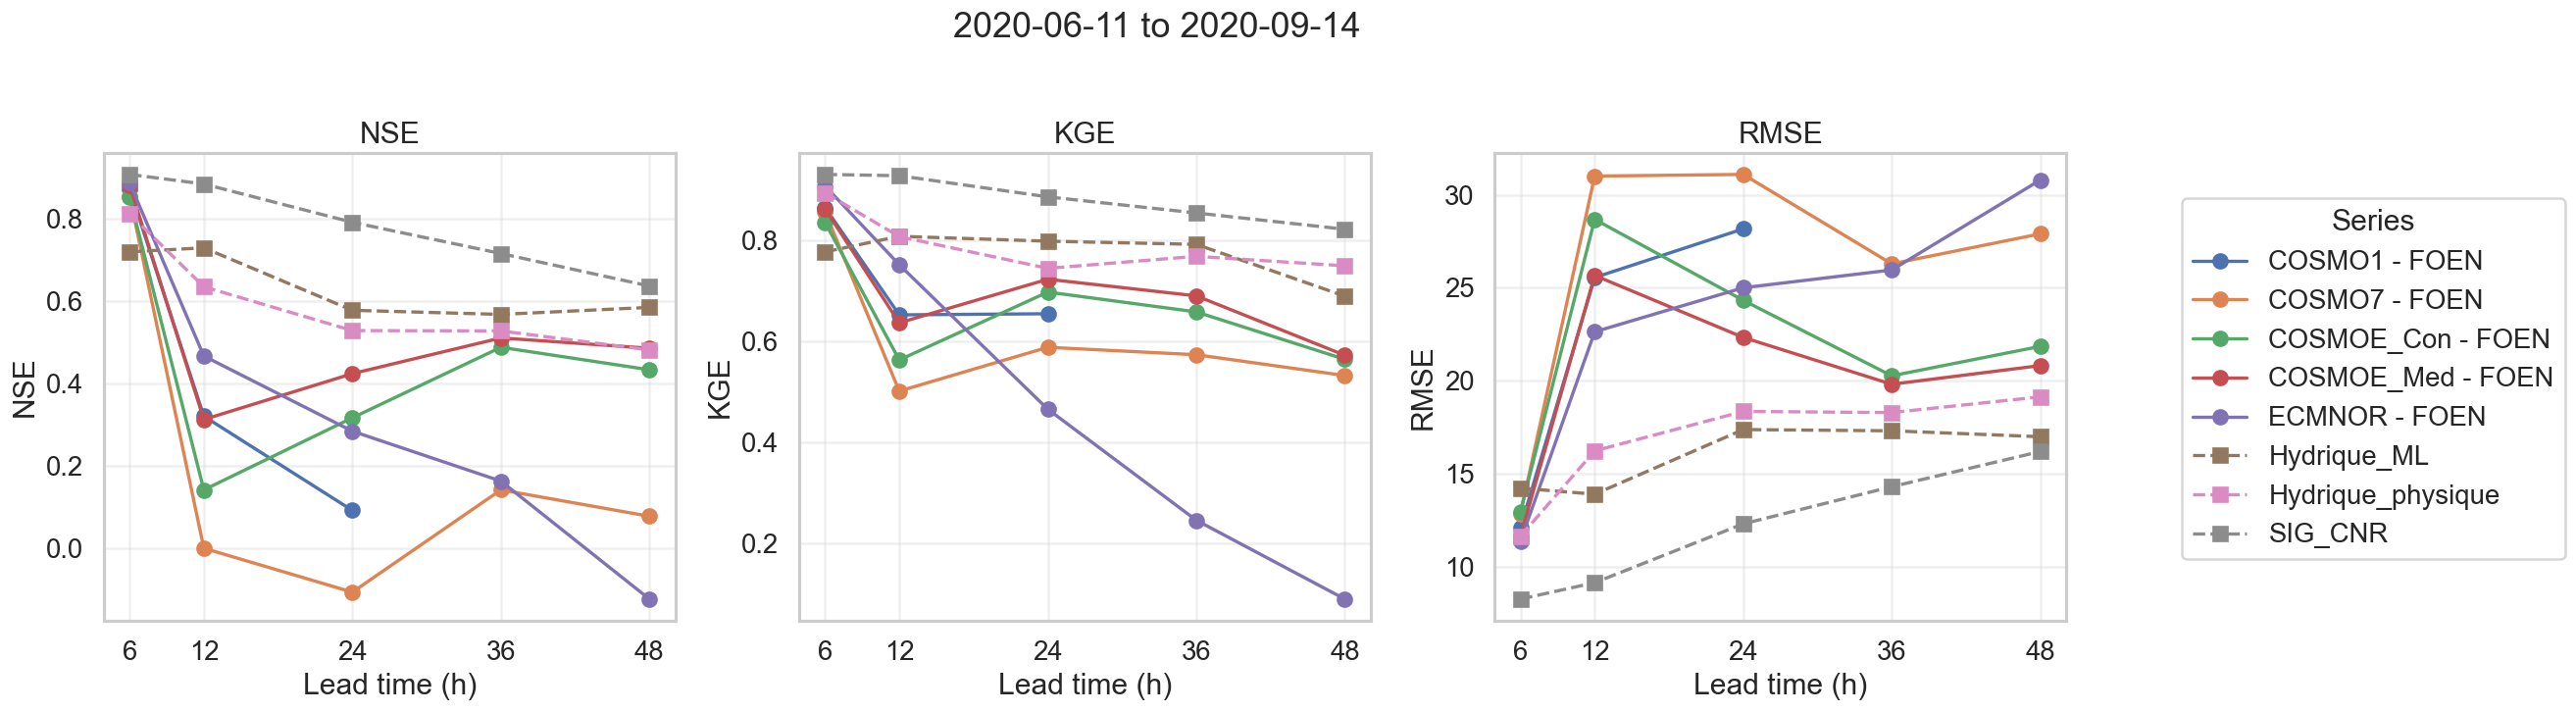

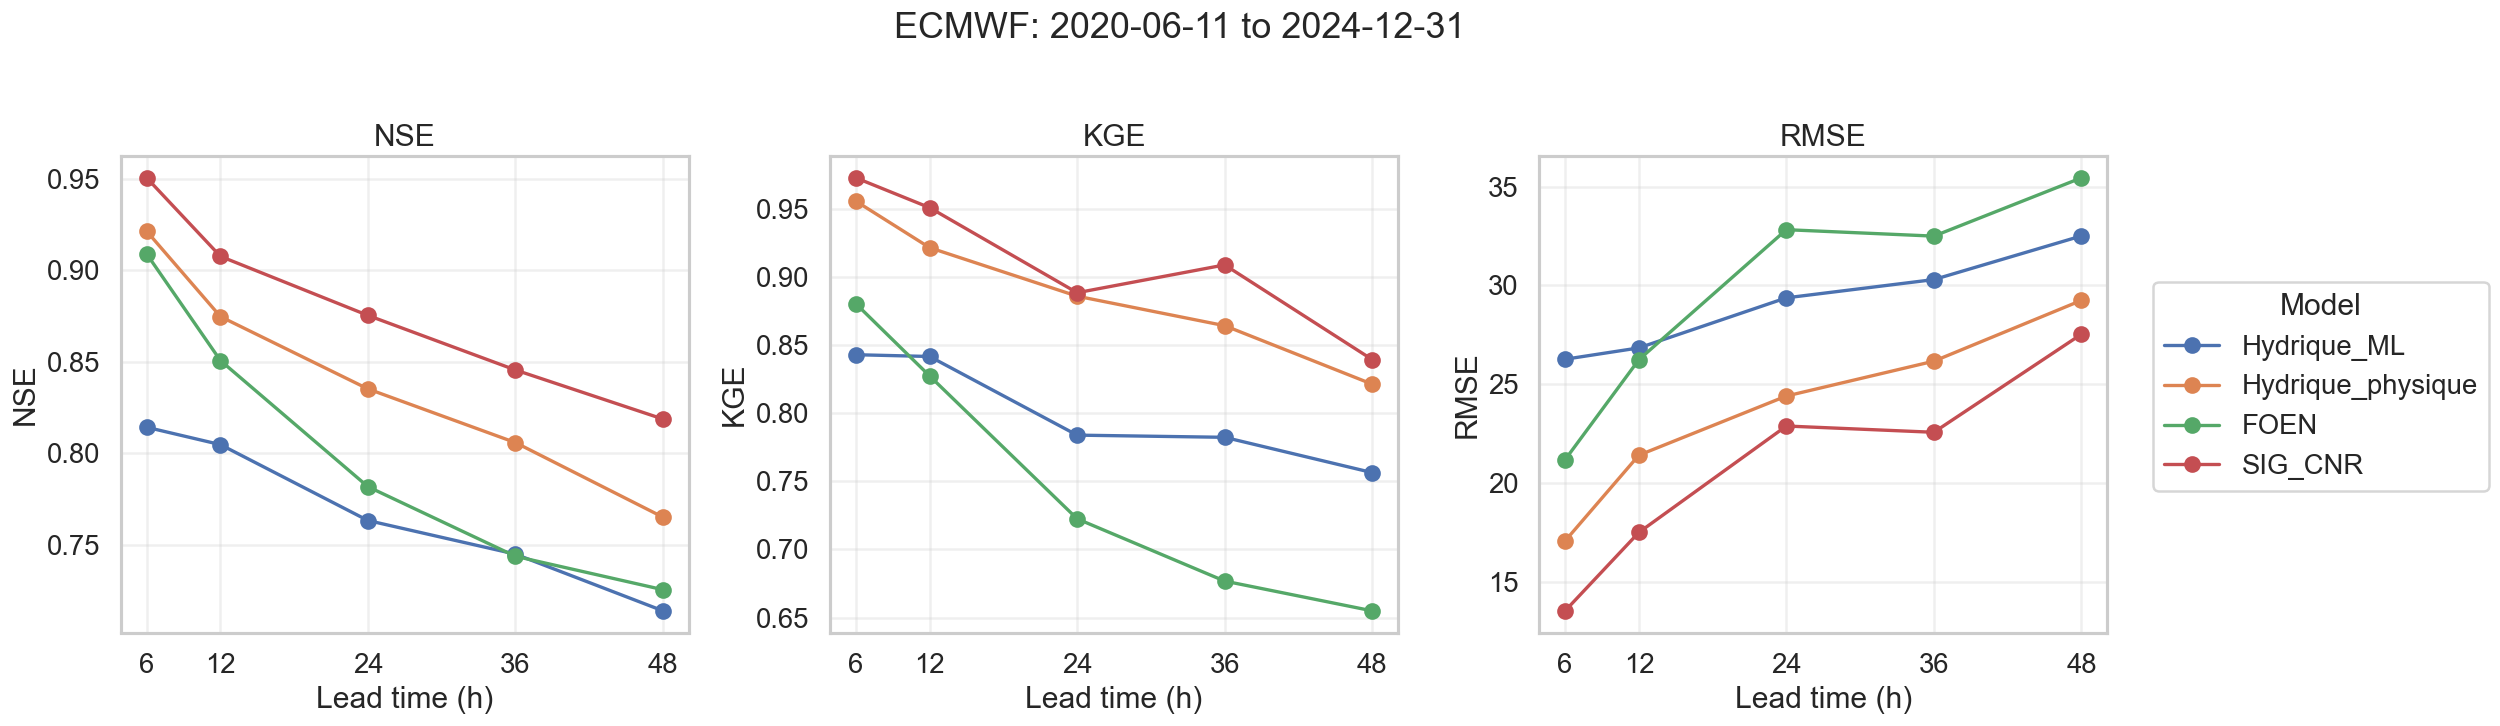

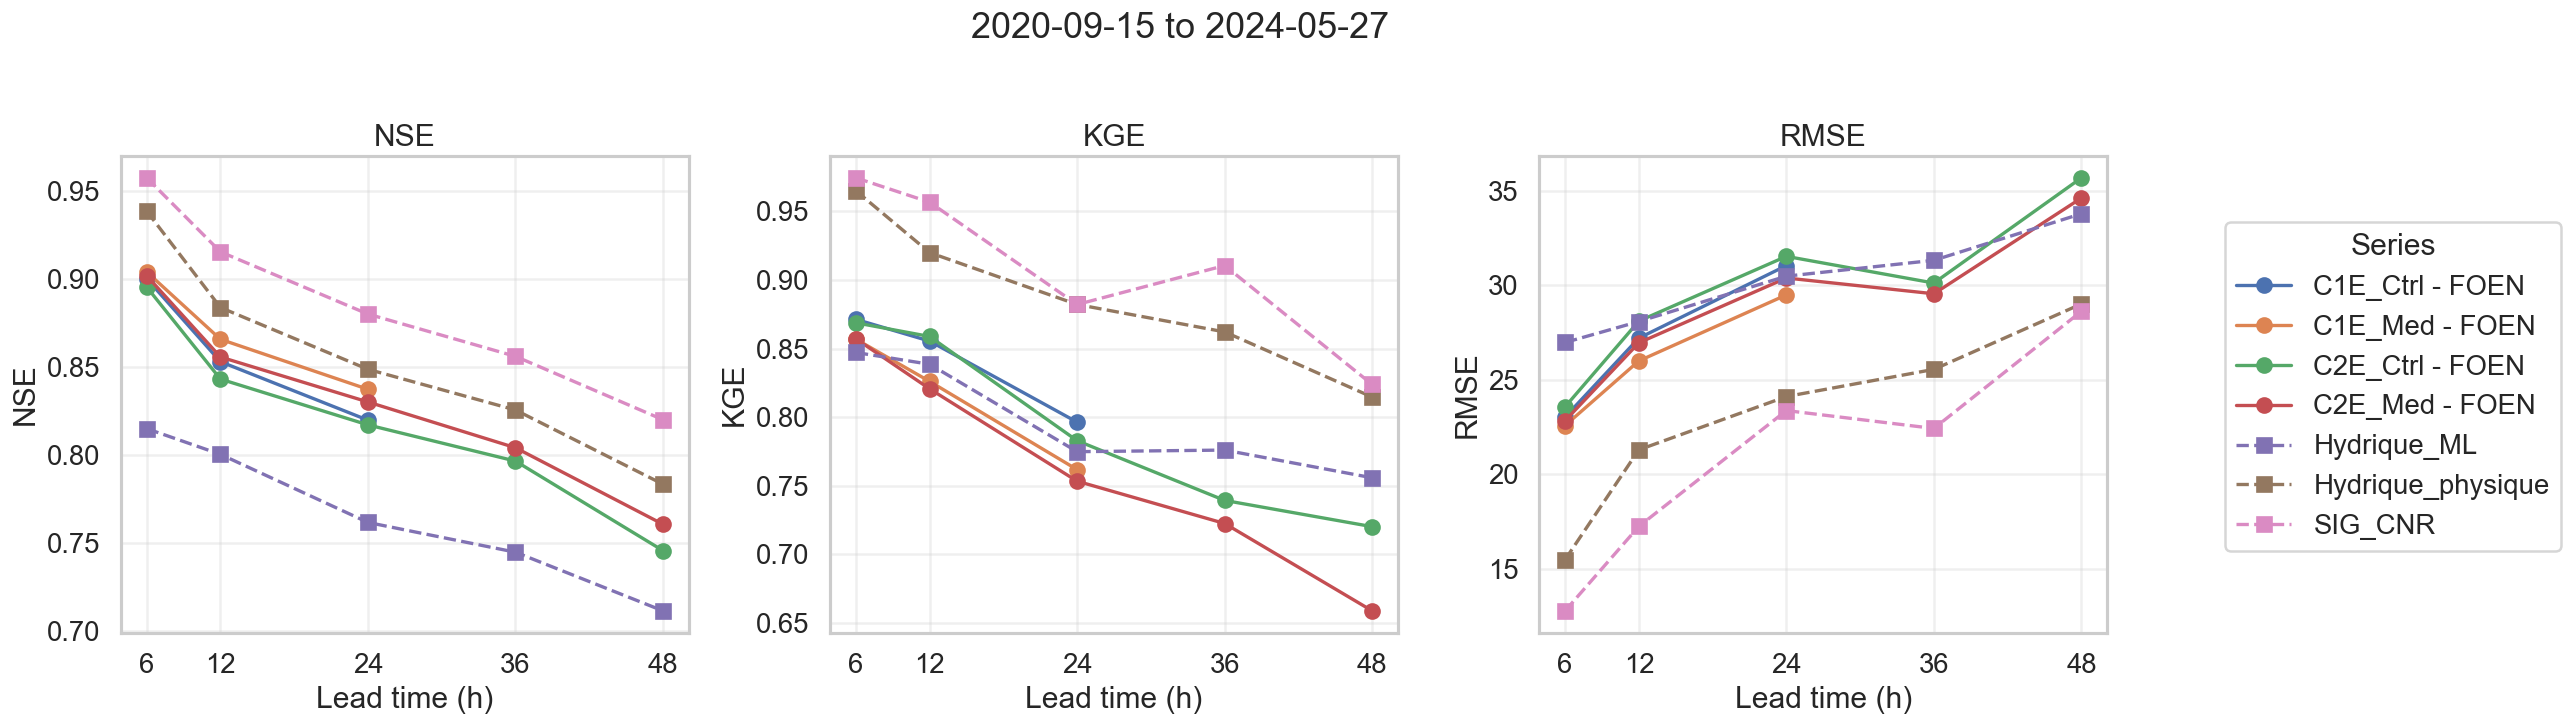

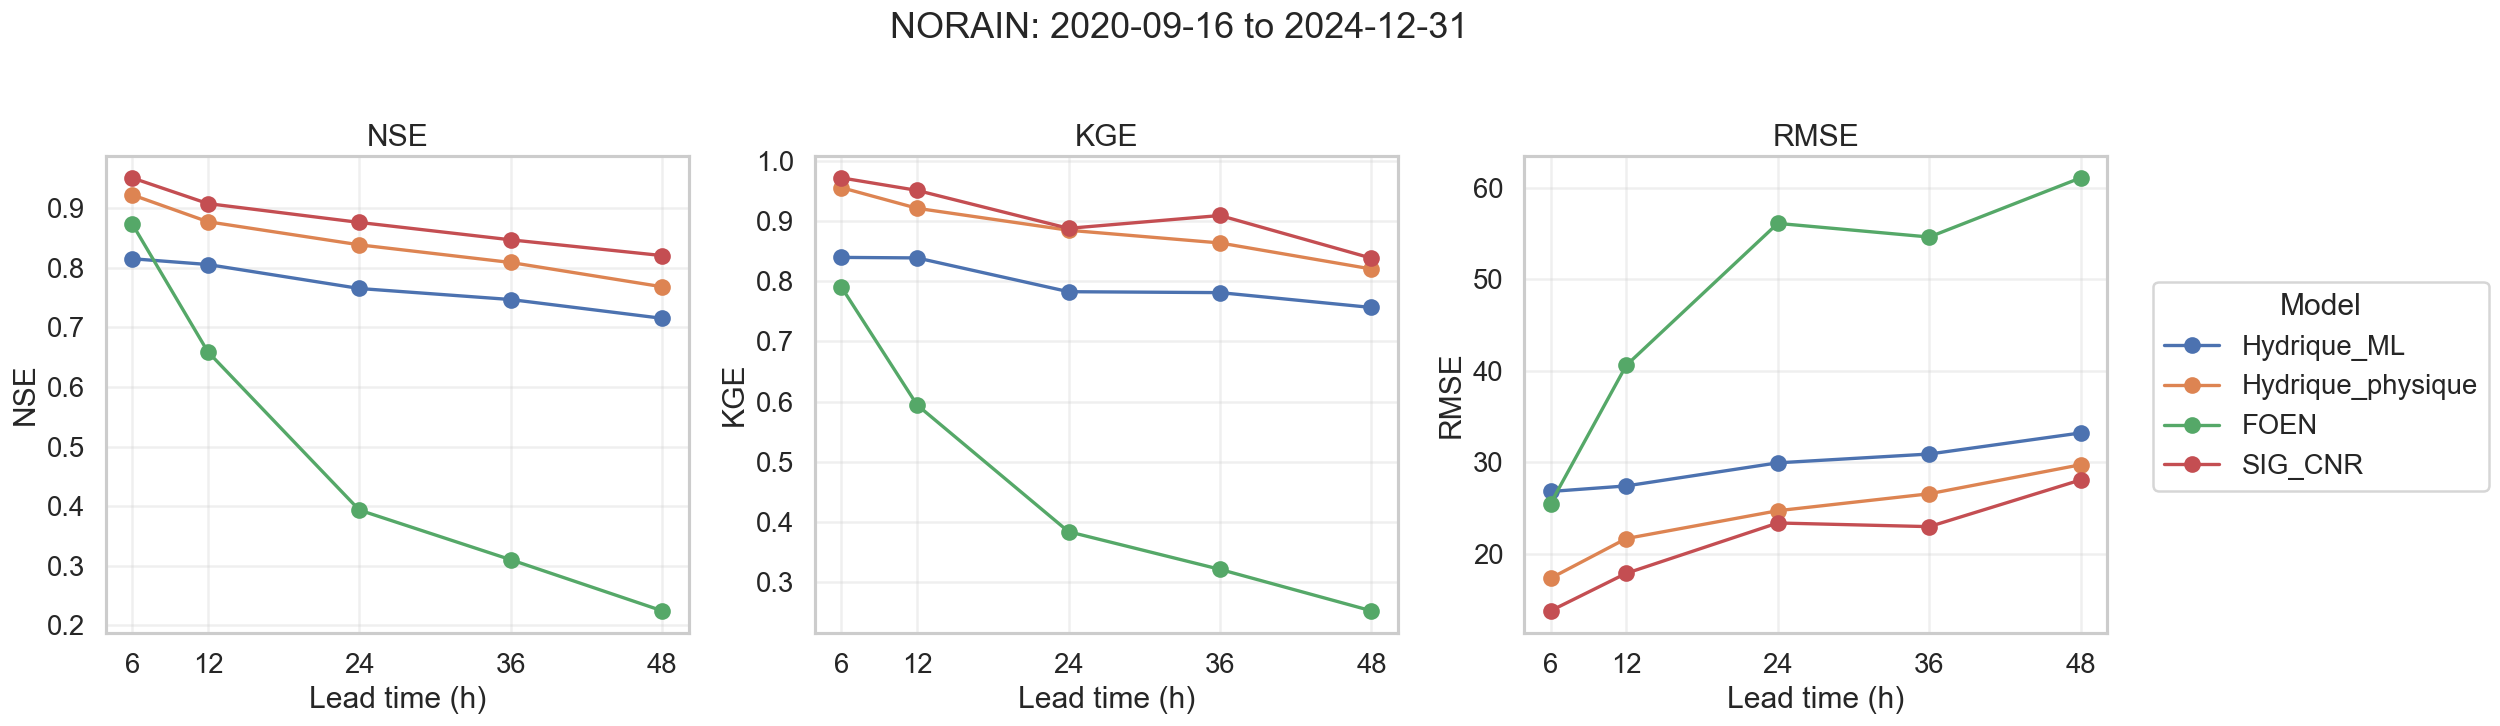

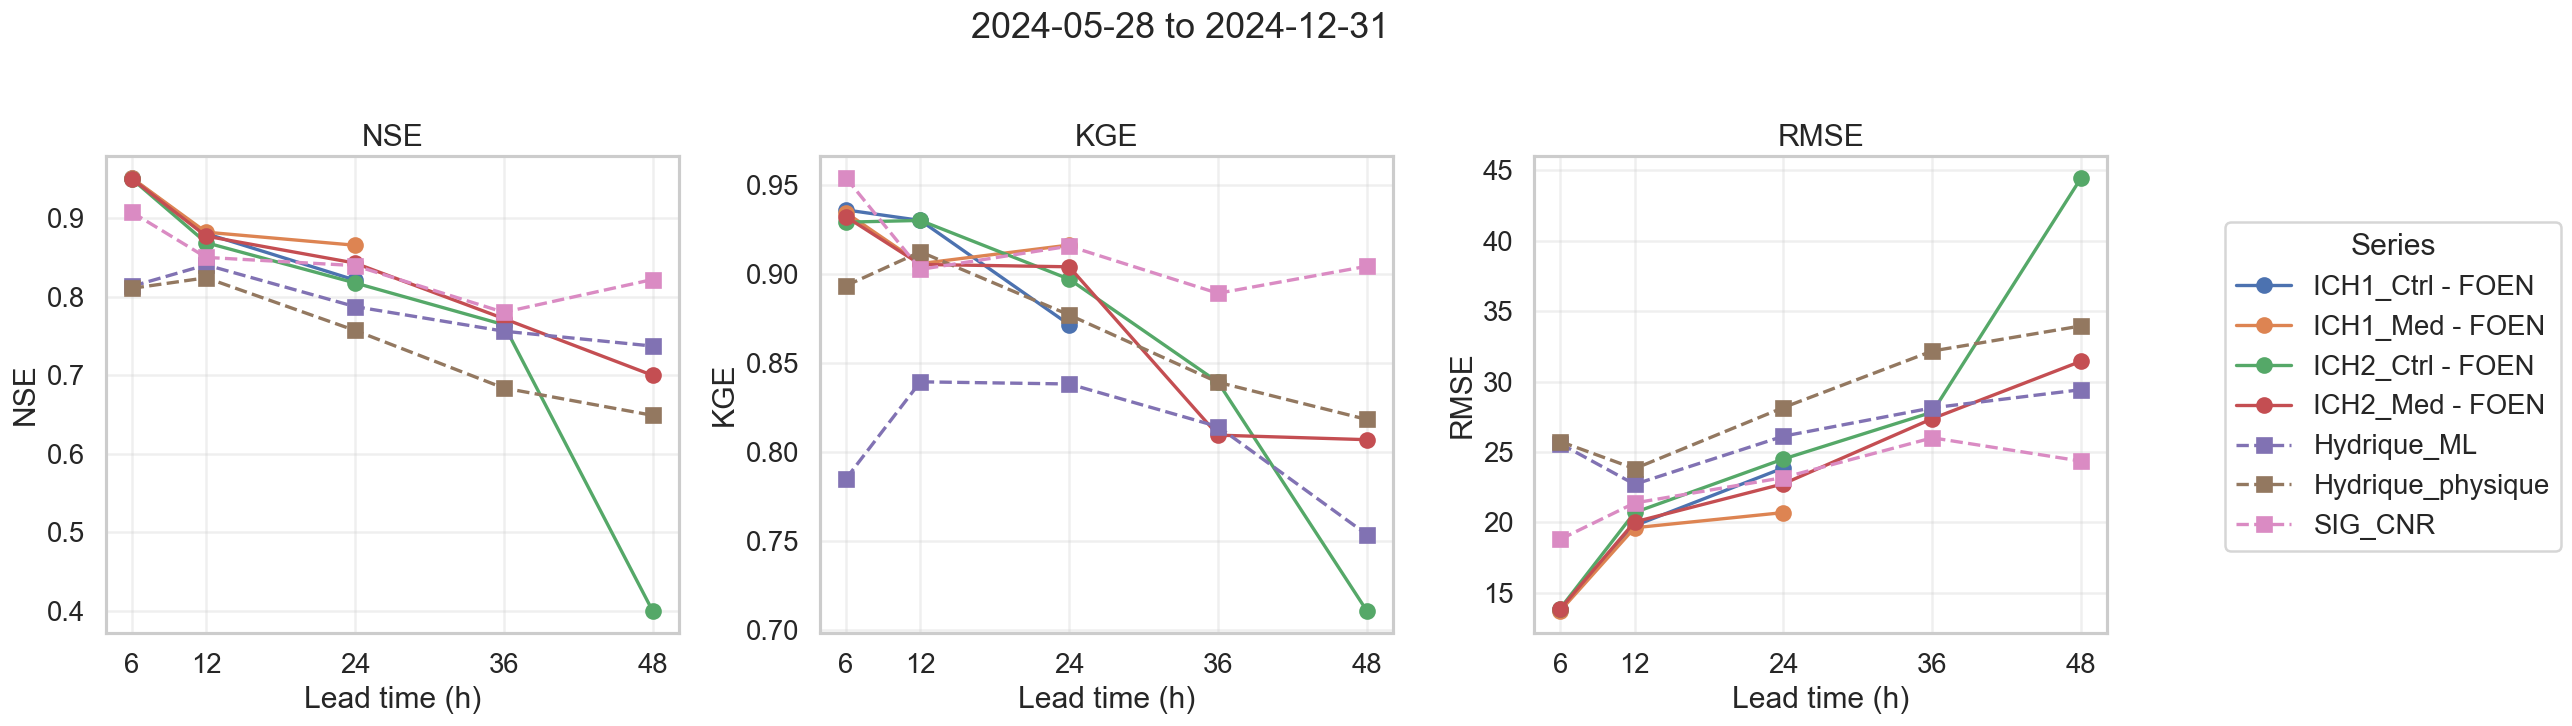

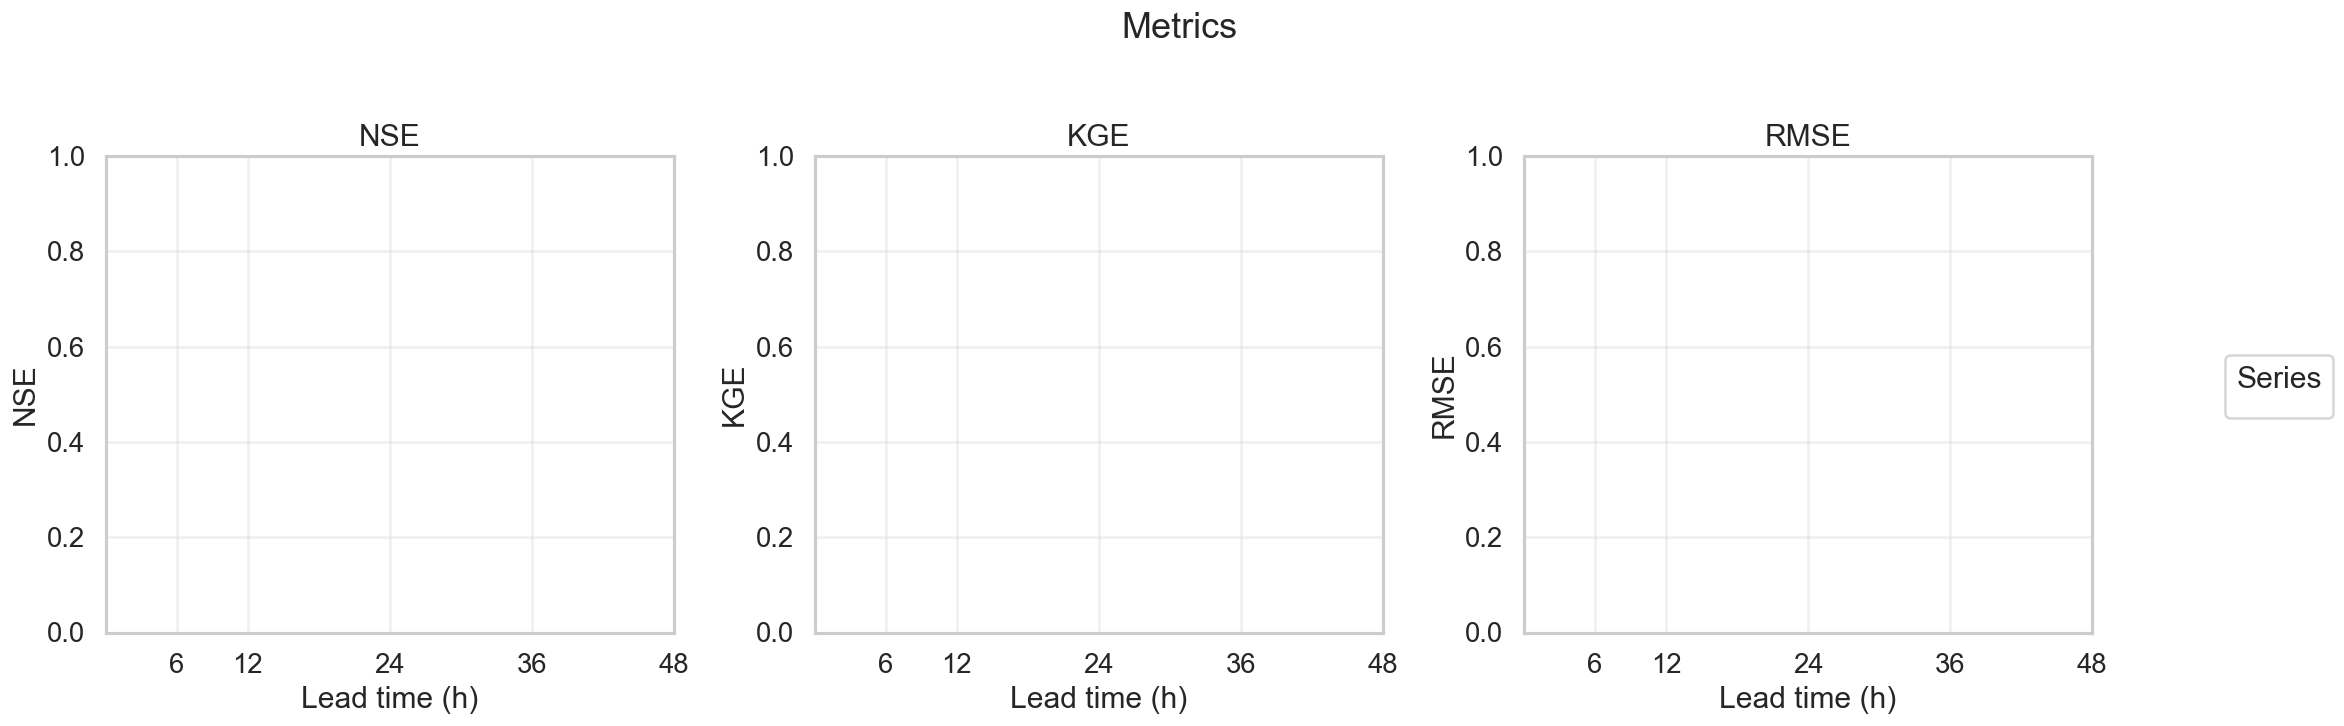

6

In [7]:
def plot_group(group: pd.DataFrame):
    group = group.sort_values(['ofev_model', 'model', 'lead_time']).copy()

    # Main figure: exclude NORAIN, ECMWF, and any Q75 rows
    main_group = group[
        ~group['ofev_model'].isin(['NORAIN', 'ECMWF']) &
        ~group['ofev_model'].str.contains('Q75', na=False)
    ].copy()

    fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 6), sharex=True)
    if len(METRICS) == 1:
        axes = [axes]

    # Plot OFEV series separately (one per ofev_model)
    ofev_rows = main_group[main_group['model'] == 'OFEV']
    ofev_models = ofev_rows['ofev_model'].unique()

    # For non-OFEV models, keep only the first ofev_model that has data up to 48h as representative
    non_ofev_models = [m for m in main_group['model'].unique() if m != 'OFEV']
    rep_series = {}
    for m in non_ofev_models:
        sub = main_group[main_group['model'] == m].sort_values(['ofev_model', 'lead_time'])
        if sub.empty:
            continue
        # consider ofev_models in appearance order
        chosen_ofev = None
        for om in sub['ofev_model'].unique():
            sub_om = sub[sub['ofev_model'] == om]
            # check whether this ofev_model provides data up to 48h
            if (sub_om['lead_time'] >= 48).any() or sub_om['lead_time'].max() >= 48:
                chosen_ofev = om
                break
        if chosen_ofev is None:
            # fallback to first occurrence
            chosen_ofev = sub['ofev_model'].iloc[0]
        rep = sub[sub['ofev_model'] == chosen_ofev].sort_values('lead_time')
        rep_series[m] = rep

    xticks = [6, 12, 24, 36, 48]

    for ax, metric in zip(axes, METRICS):
        # plot OFEV lines (one per ofev_model)
        for om in ofev_models:
            sub = ofev_rows[ofev_rows['ofev_model'] == om].sort_values('lead_time')
            if sub.empty:
                continue
            ax.plot(sub['lead_time'], sub[metric], marker='o', linewidth=2, label=f'{om} - FOEN')

        # plot representative non-OFEV series (label only by model)
        for m, rep in rep_series.items():
            ax.plot(rep['lead_time'], rep[metric], marker='s', linestyle='--', linewidth=2, label=m)

        ax.set_title(metric)
        ax.set_xlabel('Lead time (h)')
        ax.set_ylabel(metric)
        ax.set_xticks(xticks)
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()

    # Get coverage_start and coverage_end of the first OFEV model
    first_ofev_model_name = ofev_models[0] if len(ofev_models) > 0 else None
    if first_ofev_model_name is not None:
        first_ofev_data = ofev_rows[ofev_rows['ofev_model'] == first_ofev_model_name].iloc[0]
        coverage_start = first_ofev_data['coverage_start'].date()
        coverage_end = first_ofev_data['coverage_end'].date()
        title_str = f'{coverage_start} to {coverage_end}'
    else:
        title_str = f'Metrics'

    fig.legend(handles, labels, title='Series', bbox_to_anchor=(0.93, 0.5), loc='center left')
    fig.suptitle(title_str, y=1.02)
    fig.tight_layout(rect=(0, 0, 0.90, 1))
    return fig


# Secondary figures for NORAIN and ECMWF ofev_models (one figure per model per anchor)
def plot_special(group: pd.DataFrame):
    special = group[group['ofev_model'].isin(['NORAIN', 'ECMWF'])].copy()
    if special.empty:
        return []

    figs = []
    # create one figure per special ofev_model
    for om in ['NORAIN', 'ECMWF']:
        sub_all = special[special['ofev_model'] == om].sort_values(['model', 'lead_time'])
        if sub_all.empty:
            continue

        fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 6), sharex=True)
        if len(METRICS) == 1:
            axes = [axes]

        # Plot all models for this ofev_model
        models_in_ofev = sub_all['model'].unique()
        xticks = [6, 12, 24, 36, 48]
        for ax, metric in zip(axes, METRICS):
            for m in models_in_ofev:
                sub = sub_all[sub_all['model'] == m].sort_values('lead_time')
                if sub.empty:
                    continue
                label = 'FOEN' if m == 'OFEV' else m
                ax.plot(sub['lead_time'], sub[metric], marker='o', linewidth=2, label=label)

            ax.set_title(metric)
            ax.set_xlabel('Lead time (h)')
            ax.set_ylabel(metric)
            ax.set_xticks(xticks)
            ax.grid(True, alpha=0.3)

        handles, labels = axes[0].get_legend_handles_labels()

        # Get coverage_start and coverage_end for this ofev_model
        om_data = sub_all.iloc[0]
        coverage_start = om_data['coverage_start'].date()
        coverage_end = om_data['coverage_end'].date()
        title_str = f'{om}: {coverage_start} to {coverage_end}'

        fig.legend(handles, labels, title='Model', bbox_to_anchor=(0.90, 0.5), loc='center left')
        fig.suptitle(title_str, y=1.02)
        fig.tight_layout(rect=(0, 0, 0.90, 1))

        figs.append((om, fig))

    return figs


plots = []
plot_df = df.dropna(subset=['coverage_start_anchor']).copy()

for anchor, group in plot_df.groupby('coverage_start_anchor', sort=True):
    fig_main = plot_group(group)
    plots.append((anchor, 'main', fig_main))

    file_name = f'metrics_by_coverage_start_{anchor:%Y%m%d_%H%M}.png'
    fig_main.savefig(OUTPUT_DIR / file_name, dpi=200, bbox_inches='tight')
    display(fig_main)
    plt.close(fig_main)

    fig_specials = plot_special(group)
    for ofev_model_name, fig_special in fig_specials:
        plots.append((anchor, f'special_{ofev_model_name}', fig_special))
        file_name2 = f'metrics_{ofev_model_name}_{anchor:%Y%m%d_%H%M}.png'
        fig_special.savefig(OUTPUT_DIR / file_name2, dpi=200, bbox_inches='tight')
        display(fig_special)
        plt.close(fig_special)

len(plots)

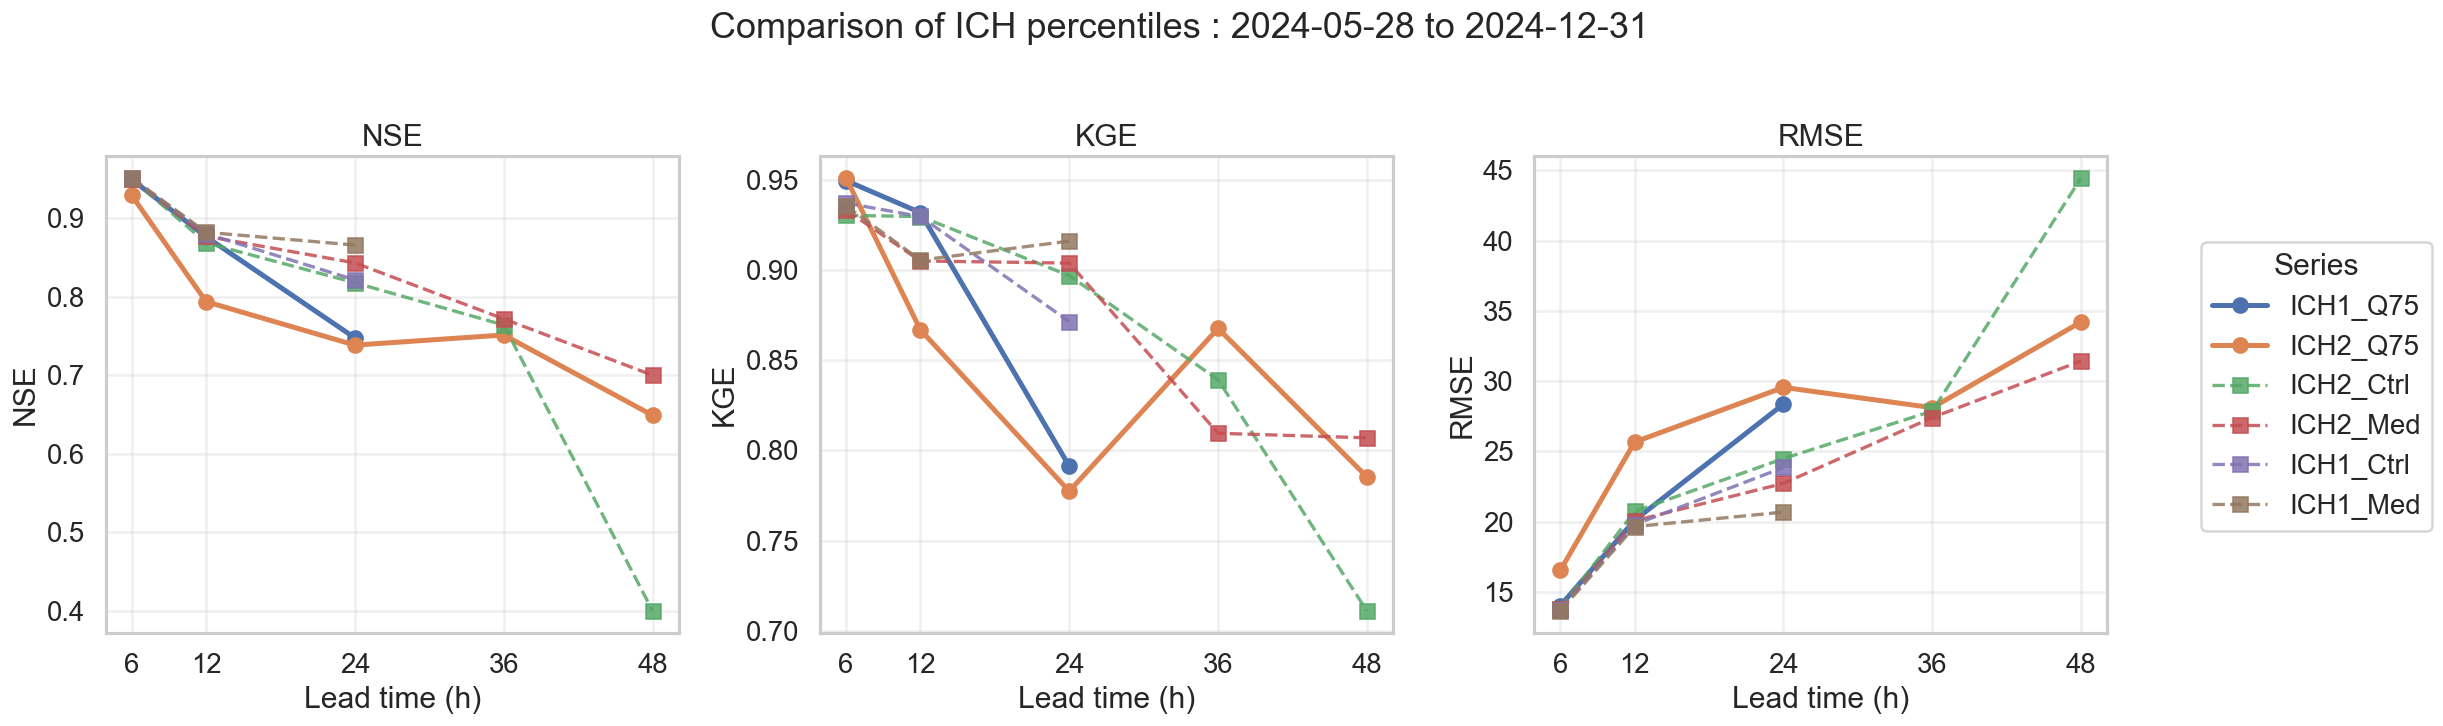

1

In [8]:
def nse(obs, sim):
    return 1 - ((obs - sim) ** 2).sum() / ((obs - obs.mean()) ** 2).sum()


def kge(obs, sim):
    r = pd.Series(obs).corr(pd.Series(sim))
    alpha = pd.Series(sim).std() / pd.Series(obs).std()
    beta = pd.Series(sim).mean() / pd.Series(obs).mean()
    return 1 - (((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2) ** 0.5)


def rmse(obs, sim):
    return (((obs - sim) ** 2).mean()) ** 0.5


def plot_q75_only(q75_data: pd.DataFrame, context_data: pd.DataFrame):
    q75_group = q75_data[
        (q75_data['model'].eq('OFEV')) &
        (q75_data['ofev_model'].str.contains('Q75', na=False))
    ].copy()
    if q75_group.empty:
        return None

    # Use the anchor of ICH2_Q75 for the background context models.
    ich2_anchor = q75_group.loc[q75_group['ofev_model'].eq('ICH2_Q75'), 'coverage_start_anchor'].dropna()
    if not ich2_anchor.empty:
        target_anchor = ich2_anchor.iloc[0]
    else:
        target_anchor = q75_group['coverage_start_anchor'].dropna().iloc[0]

    # Keep both ICH1_Q75 and ICH2_Q75 on the same plot.
    q75_rows = q75_group.copy().sort_values(['ofev_model', 'lead_time'])
    target_row = q75_rows[q75_rows['ofev_model'].eq('ICH2_Q75')].sort_values('lead_time').iloc[0]
    coverage_start = pd.Timestamp(target_row['coverage_start'])
    coverage_end = pd.Timestamp(target_row['coverage_end'])

    context_group = context_data[context_data['coverage_start_anchor'].eq(target_anchor)].copy()
    context_group = context_group[
        ~(context_group['model'].eq('OFEV') & context_group['ofev_model'].str.contains('Q75', na=False))
    ].sort_values(['model', 'ofev_model', 'lead_time'])

    obs_path = BASE_DIR / 'data' / 'Data Fornisseurs' / 'ARVE' / '2170_Abfluss_10-Min-Mittel_1999-01-01_2024-12-31.csv'
    det_path = BASE_DIR / 'outputs' / 'OFEV_probabilistic' / 'station2170_deterministic.csv'

    obs = pd.read_csv(obs_path, sep=';', encoding='cp1252', skiprows=8)
    obs.columns = obs.columns.str.strip()
    obs['Zeitstempel'] = pd.to_datetime(obs['Zeitstempel'])
    obs['Wert'] = pd.to_numeric(obs['Wert'], errors='coerce')
    obs = obs[['Zeitstempel', 'Wert']].rename(columns={'Wert': 'Q_obs'}).set_index('Zeitstempel')
    obs_h = obs.resample('1h').mean()

    det = pd.read_csv(det_path)
    det.columns = det.columns.str.strip()
    det['issue_time'] = pd.to_datetime(det['issue_time'])
    det['valid_time'] = pd.to_datetime(det['valid_time'])
    det['lead_time_h'] = pd.to_numeric(det['lead_time_h'], errors='coerce')
    det = det[det['model'].isin(['ICH2_Ctrl', 'ICH2_Med', 'ICH1_Q75', 'ICH1_Ctrl', 'ICH1_Med'])].copy()
    det = det.groupby(['model', 'valid_time', 'lead_time_h'], as_index=False)['Q'].median()

    obs_window = obs_h.loc[coverage_start:coverage_end]
    det_rows = []
    for model_name in ['ICH2_Ctrl', 'ICH2_Med', 'ICH1_Ctrl', 'ICH1_Med']:
        sub_model = det[det['model'].eq(model_name)]
        for lt in [6, 12, 24, 36, 48]:
            sub_lt = sub_model[sub_model['lead_time_h'].round().eq(lt)].copy()
            if sub_lt.empty:
                continue

            merged = pd.merge(
                obs_window,
                sub_lt[['valid_time', 'Q']],
                left_index=True,
                right_on='valid_time',
                how='inner',
            )
            if merged.empty:
                continue

            obs_v = merged['Q_obs'].to_numpy()
            sim_v = merged['Q'].to_numpy()
            det_rows.append({
                'ofev_model': 'ICH2_Q75',
                'coverage_start_anchor': target_anchor,
                'coverage_start': coverage_start,
                'coverage_end': coverage_end,
                'model': model_name,
                'lead_time': lt,
                'NSE': nse(obs_v, sim_v),
                'KGE': kge(obs_v, sim_v),
                'RMSE': rmse(obs_v, sim_v),
            })

    det_context_group = pd.DataFrame(det_rows)
    if not det_context_group.empty:
        context_group = pd.concat([context_group, det_context_group], ignore_index=True, sort=False)

    fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 6), sharex=True)
    if len(METRICS) == 1:
        axes = [axes]

    xticks = [6, 12, 24, 36, 48]
    q75_models = q75_rows['ofev_model'].dropna().unique()
    context_models = [m for m in context_group['model'].dropna().unique() if m in ['ICH1_Ctrl', 'ICH1_Med', 'ICH2_Ctrl', 'ICH2_Med']]

    for ax, metric in zip(axes, METRICS):
        for om in q75_models:
            sub = q75_rows[q75_rows['ofev_model'] == om].sort_values('lead_time')
            if sub.empty:
                continue
            ax.plot(sub['lead_time'], sub[metric], marker='o', linewidth=3, label=om)

        # Plot only the ICH1/ICH2 control and median series, no Hydrique or SIG-CNR.
        for model_name in context_models:
            sub = context_group[context_group['model'] == model_name].sort_values('lead_time')
            if sub.empty:
                continue
            sub = sub.groupby('lead_time', as_index=False)[metric].mean()
            if sub.empty:
                continue
            ax.plot(sub['lead_time'], sub[metric], marker='s', linestyle='--', linewidth=2, alpha=0.85, label=model_name)

        ax.set_title(metric)
        ax.set_xlabel('Lead time (h)')
        ax.set_ylabel(metric)
        ax.set_xticks(xticks)
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    coverage_start_date = coverage_start.date()
    coverage_end_date = coverage_end.date()

    fig.legend(handles, labels, title='Series', bbox_to_anchor=(0.92, 0.5), loc='center left')
    fig.suptitle(f'Comparison of ICH percentiles : {coverage_start_date} to {coverage_end_date}', y=1.02)
    fig.tight_layout(rect=(0, 0, 0.90, 1))
    return fig


plots_q75 = []
q75_all = plot_df[
    plot_df['model'].eq('OFEV') &
    plot_df['ofev_model'].str.contains('Q75', na=False)
].copy()

fig_q75 = plot_q75_only(q75_all, plot_df)
if fig_q75 is not None:
    plots_q75.append(fig_q75)
    file_name_q75 = 'metrics_q75_only_with_ICH2_ICH1.png'
    fig_q75.savefig(OUTPUT_DIR / file_name_q75, dpi=200, bbox_inches='tight')
    display(fig_q75)
    plt.close(fig_q75)

len(plots_q75)